<a href="https://www.kaggle.com/code/sonawanelalitsunil/used-cars-market-analysis-from-cars24-ml-86?scriptVersionId=228803315" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/used-car-price-data-from-cars24/cars24data.csv


## Title: Used Cars Market Analysis from Cars24 Data

#### Description: Analyzing trends in the used car market using scraped data from Cars24. Insights include price distribution, popular brands, demand patterns, and factors affecting resale value.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/used-car-price-data-from-cars24/cars24data.csv')

In [3]:
df.head()

,Model Name,Price,Manufacturing_year,Engine capacity,Spare key,Transmission,KM driven,Ownership,Fuel type,Imperfections,Repainted Parts
0,2017 Maruti Swift VXI,561000,2017,1197,No,Manual,25847,2,Petrol,6,2
1,2016 Maruti Baleno DELTA PETROL 1.2,498000,2016,1197,Yes,Manual,55511,2,Petrol,12,1
2,2020 Maruti Swift VXI,577000,2020,1197,No,Manual,47110,1,Petrol,4,2
3,2022 Maruti Ertiga VXI AT SHVS,1084000,2022,1462,Yes,Automatic,35378,1,Petrol,2,3
4,2019 Maruti Dzire VXI,603000,2019,1197,Yes,Manual,91856,1,Petrol,3,2


In [4]:
df.tail()

,Model Name,Price,Manufacturing_year,Engine capacity,Spare key,Transmission,KM driven,Ownership,Fuel type,Imperfections,Repainted Parts
1440,2021 Maruti Ertiga VXI SHVS,862000,2021,1462,No,Manual,19901,1,Petrol,1,0
1441,2015 Maruti Ciaz ZXI,507000,2015,1373,No,Manual,50022,1,Petrol,5,2
1442,2019 Maruti Baleno DELTA PETROL 1.2,554000,2019,1197,Yes,Manual,58679,1,Petrol,24,4
1443,2017 Maruti Ciaz S 1.4 MT PETROL,557000,2017,1373,Yes,Manual,73948,2,Petrol,4,5
1444,2012 Maruti Wagon R 1.0 LXI,256000,2012,998,No,Manual,55994,1,Petrol,20,9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Model Name          1445 non-null   object
 1   Price               1445 non-null   int64 
 2   Manufacturing_year  1445 non-null   int64 
 3   Engine capacity     1445 non-null   int64 
 4   Spare key           1445 non-null   object
 5   Transmission        1445 non-null   object
 6   KM driven           1445 non-null   int64 
 7   Ownership           1445 non-null   int64 
 8   Fuel type           1445 non-null   object
 9   Imperfections       1445 non-null   int64 
 10  Repainted Parts     1445 non-null   int64 
dtypes: int64(7), object(4)
memory usage: 124.3+ KB


In [6]:
df.describe()

,Price,Manufacturing_year,Engine capacity,KM driven,Ownership,Imperfections,Repainted Parts
count,1.445000e+03,1445.000000,1445.000000,1445.000000,1445.000000,1445.000000,1445.000000
mean,5.263543e+05,2017.817301,1142.104498,50588.903114,1.285121,9.597232,3.228374
std,1.963696e+05,2.986554,169.020818,27339.562631,0.489877,8.398637,3.364578
min,1.390000e+05,2010.000000,796.000000,1207.000000,1.000000,0.000000,0.000000
25%,3.900000e+05,2016.000000,998.000000,28803.000000,1.000000,3.000000,0.000000
50%,5.010000e+05,2018.000000,1197.000000,47849.000000,1.000000,8.000000,2.000000
75%,6.310000e+05,2020.000000,1197.000000,70337.000000,2.000000,14.000000,5.000000
max,1.599000e+06,2023.000000,1462.000000,124716.000000,3.000000,43.000000,27.000000


In [7]:
df.isnull().sum()

Model Name            0
Price                 0
Manufacturing_year    0
Engine capacity       0
Spare key             0
Transmission          0
KM driven             0
Ownership             0
Fuel type             0
Imperfections         0
Repainted Parts       0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Model Name            object
Price                  int64
Manufacturing_year     int64
Engine capacity        int64
Spare key             object
Transmission          object
KM driven              int64
Ownership              int64
Fuel type             object
Imperfections          int64
Repainted Parts        int64
dtype: object

In [10]:
df.corr

<bound method DataFrame.corr of                                Model Name    Price  Manufacturing_year  \
0                   2017 Maruti Swift VXI   561000                2017   
1     2016 Maruti Baleno DELTA PETROL 1.2   498000                2016   
2                   2020 Maruti Swift VXI   577000                2020   
3          2022 Maruti Ertiga VXI AT SHVS  1084000                2022   
4                   2019 Maruti Dzire VXI   603000                2019   
...                                   ...      ...                 ...   
1440          2021 Maruti Ertiga VXI SHVS   862000                2021   
1441                 2015 Maruti Ciaz ZXI   507000                2015   
1442  2019 Maruti Baleno DELTA PETROL 1.2   554000                2019   
1443     2017 Maruti Ciaz S 1.4 MT PETROL   557000                2017   
1444          2012 Maruti Wagon R 1.0 LXI   256000                2012   

      Engine capacity Spare key Transmission  KM driven  Ownership Fuel type  \

In [11]:
df.shape

(1445, 11)

In [12]:
df.columns

Index(['Model Name', 'Price', 'Manufacturing_year', 'Engine capacity',
       'Spare key', 'Transmission', 'KM driven', 'Ownership', 'Fuel type',
       'Imperfections', 'Repainted Parts'],
      dtype='object')

## data visualizations

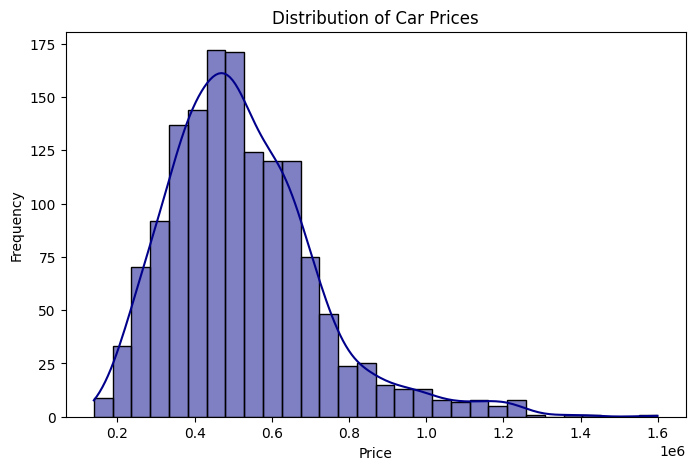

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=30, kde=True, color='darkblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

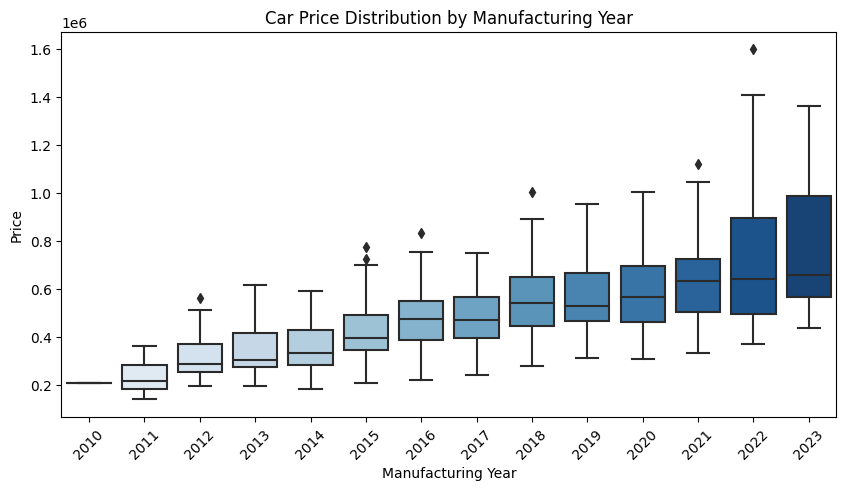

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Manufacturing_year'], y=df['Price'], palette='Blues')
plt.xticks(rotation=45)
plt.title('Car Price Distribution by Manufacturing Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Price')
plt.show()

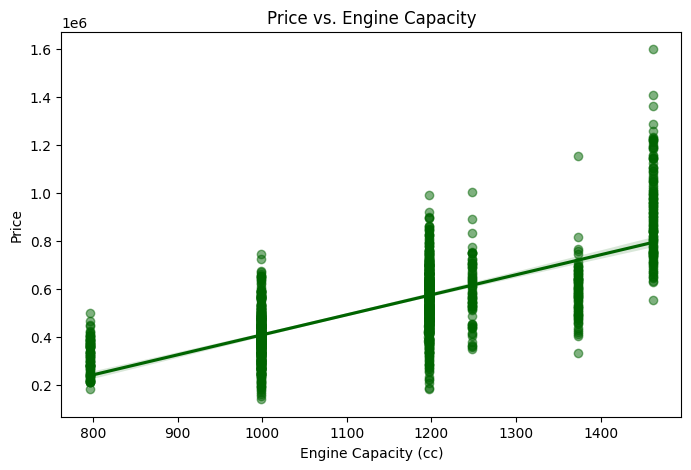

In [15]:
plt.figure(figsize=(8, 5))
sns.regplot(x=df['Engine capacity'], y=df['Price'], scatter_kws={'alpha':0.5}, color='darkgreen')
plt.title('Price vs. Engine Capacity')
plt.xlabel('Engine Capacity (cc)')
plt.ylabel('Price')
plt.show()

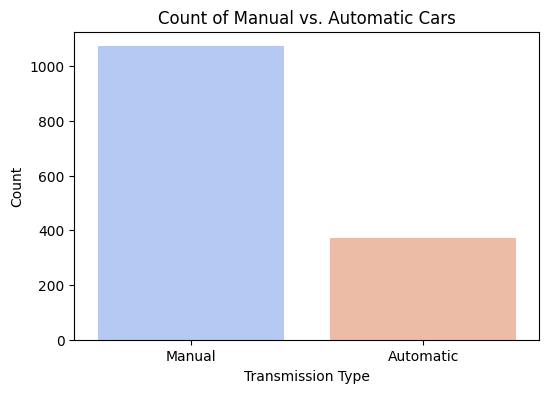

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Transmission'], palette='coolwarm')
plt.title('Count of Manual vs. Automatic Cars')
plt.xlabel('Transmission Type')
plt.ylabel('Count')
plt.show()

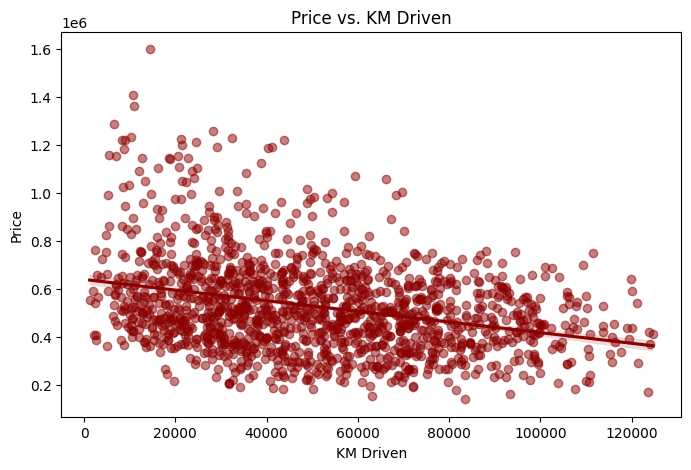

In [17]:
plt.figure(figsize=(8, 5))
sns.regplot(x=df['KM driven'], y=df['Price'], scatter_kws={'alpha':0.5}, color='darkred')
plt.title('Price vs. KM Driven')
plt.xlabel('KM Driven')
plt.ylabel('Price')
plt.show()

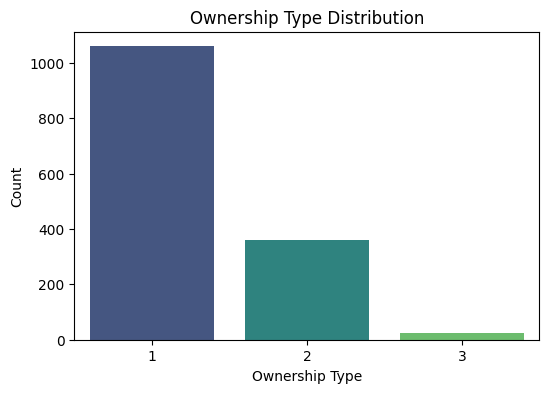

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Ownership'], palette='viridis')
plt.title('Ownership Type Distribution')
plt.xlabel('Ownership Type')
plt.ylabel('Count')
plt.show()

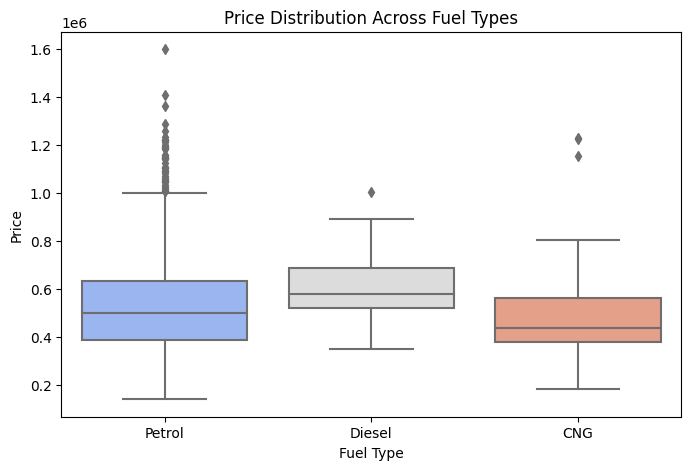

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Fuel type'], y=df['Price'], palette='coolwarm')
plt.title('Price Distribution Across Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

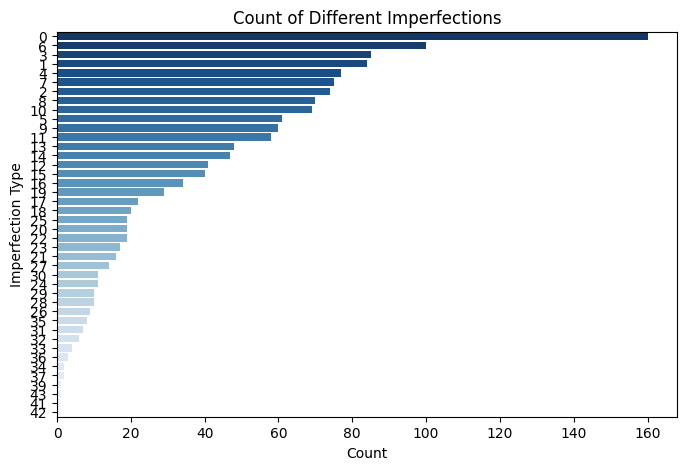

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(y=df['Imperfections'], order=df['Imperfections'].value_counts().index, palette='Blues_r')
plt.title('Count of Different Imperfections')
plt.xlabel('Count')
plt.ylabel('Imperfection Type')
plt.show()

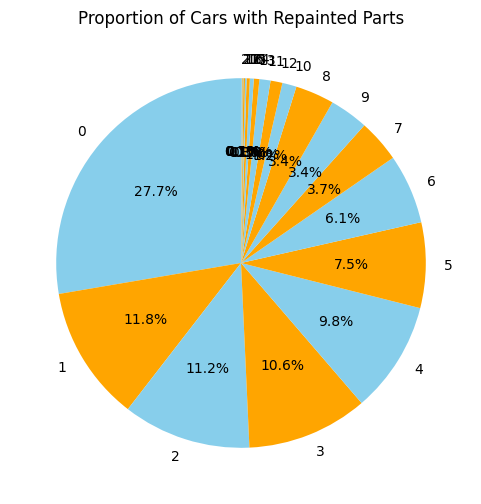

In [21]:
plt.figure(figsize=(6, 6))
df['Repainted Parts'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'orange'], startangle=90)
plt.title('Proportion of Cars with Repainted Parts')
plt.ylabel('')
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [23]:
df.fillna(df.median(numeric_only=True), inplace=True)  # Fill numeric with median
df.fillna(df.mode().iloc[0], inplace=True)

In [24]:
# Encode categorical columns
cat_cols = ['Model Name', 'Spare key', 'Transmission', 'Ownership', 'Fuel type', 'Imperfections', 'Repainted Parts']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [25]:
# Select features and target
X = df.drop(columns=['Price'])  # Independent variables
y = df['Price']

In [26]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
scaler = StandardScaler()
X_train[['Engine capacity', 'KM driven', 'Manufacturing_year']] = scaler.fit_transform(X_train[['Engine capacity', 'KM driven', 'Manufacturing_year']])
X_test[['Engine capacity', 'KM driven', 'Manufacturing_year']] = scaler.transform(X_test[['Engine capacity', 'KM driven', 'Manufacturing_year']])

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

In [29]:
# Train models and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {"R² Score": r2, "MAE": mae}


In [30]:
# Display results
results_df = pd.DataFrame(results).T
print(results_df)

                   R² Score           MAE
Linear Regression  0.803813  61020.224527
Decision Tree      0.803520  57910.034602
Random Forest      0.862652  47078.581315
XGBoost            0.864392  46320.283142


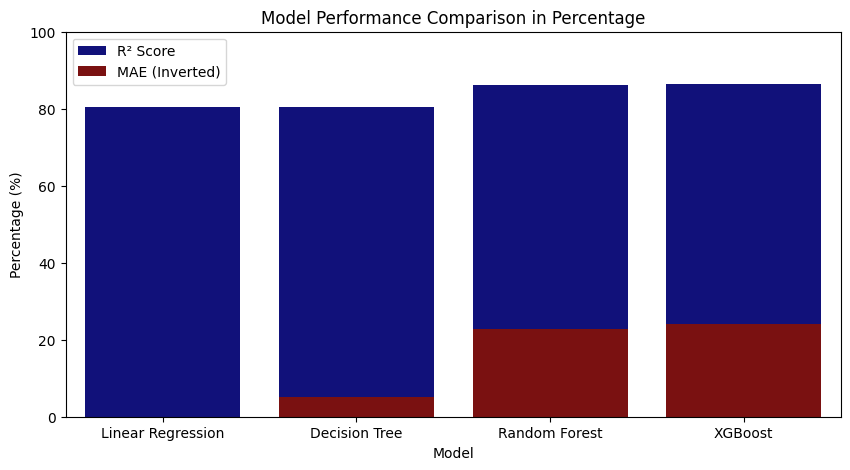

In [31]:
models = ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"]
r2_scores = [0.803813, 0.803520, 0.862652, 0.864392]
mae_values = [61020.22, 57910.03, 47078.58, 46320.28]

# Convert R² scores to percentages
r2_percent = [r * 100 for r in r2_scores]

# Normalize MAE to percentage (lower is better, so we reverse the scale)
max_mae = max(mae_values)
mae_percent = [(1 - (m / max_mae)) * 100 for m in mae_values]

# Create DataFrame for plotting
data = pd.DataFrame({"Model": models, "R² Score (%)": r2_percent, "MAE (%)": mae_percent})

# Plot the percentage bar graph
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="R² Score (%)", data=data, color="darkblue", label="R² Score")
sns.barplot(x="Model", y="MAE (%)", data=data, color="darkred", label="MAE (Inverted)")

plt.title("Model Performance Comparison in Percentage")
plt.ylabel("Percentage (%)")
plt.legend()
plt.ylim(0, 100)  # Set percentage limit
plt.show()


## Thank you!!!...pls upvote!!!!